# Large-scale Drag Partition Visualization
This notebook visualizes the NetCDF output from the Drag Partition pipeline using `hvplot`, `datashader`, and `dask`.
It is optimized for large datasets by using a LocalCluster and careful memory management for Datashader integration.

In [1]:
import xarray as xr
# import hvplot.xarray
# import geoviews as gv
# import holoviews as hv
from dask.distributed import Client, LocalCluster
import glob

# Initialize Dask Cluster for parallel processing
# This is crucial for handling large datasets that don't fit in RAM
cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit='30GB')
client = Client(cluster)
print(f"Dask dashboard available at: {client.dashboard_link}")
print(client)
# Set plotting backend
# hv.extension('bokeh')

Dask dashboard available at: http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:41431' processes=8 threads=8, memory=223.52 GiB>


In [ ]:
import hvplot.xarray
import geoviews as gv
import holoviews as hv
# Set plotting backend
hv.extension('bokeh')

In [2]:
# Define path
output_path = 'output/drag_partition_NESDIS_*.nc'
files = sorted(glob.glob(output_path))
print(f"Found {len(files)} files.")

ds = xr.open_mfdataset(
    files, 
    combine='by_coords', 
    parallel=True, 
    chunks={'time': -1, 'lat': 3600, 'lon': 7200}
)

# CRITICAL OPTIMIZATION FOR DATASHADER:
# Pre-load coordinate arrays into memory. 
# Datashader often fails if it has to compute coordinates lazily during rendering.
ds['lat'] = ds['lat'].compute()
ds['lon'] = ds['lon'].compute()
# Fill NaNs with 0 to ensure numeric types for Numba/Datashader
# This is a common requirement to prevent typing errors in aggregation
# ds = ds.fillna(0.0)

print("Dataset Info:")
print(ds)

Found 449 files.
Dataset Info:
<xarray.Dataset> Size: 279GB
Dimensions:  (time: 448, lat: 3600, lon: 7200)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2024-10-10 2024-10-11 ... 2026-01-01
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.82 ... -89.88 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    feff     (time, lat, lon) float64 93GB dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    feff2    (time, lat, lon) float64 93GB dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    ra_bare  (time, lat, lon) float64 93GB dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
Attributes:
    history:  Calculated at 2026-02-04T17:13:21 using the hybrid drag partiti...


In [ ]:
for i in files:
    try: 
        xr.open_dataset(i)
    except Exception as e:
        print(f"Error opening {i}: {e}")

In [ ]:
from holoviews.operation.datashader import regrid

# Define a function to visualize a single time step
# Returns a raw GeoViews Image element
def view_timestep(time):
    # 1. Fetch data for this time step into memory (numpy array)
    #    This avoids Dask/Numba typing errors.
    arr = feff2.where(feff2 < 1).where(feff2 > .3).sel(month=time).compute()
    
    # 2. Return a GeoViews Image object
    #    REMOVED 'coords' argument which caused TypeError.
    #    Constructing Image with (data, kdims, vdims)
    return gv.Image(arr, kdims=['lon', 'lat'], vdims=['feff'])

# Create the DynamicMap for the time dimension
dmap = hv.DynamicMap(view_timestep, kdims=[hv.Dimension('month', values=feff2['month'].values)])

# Apply regridding (optimized rasterization for grids)
# interpolation='bilinear' improves the "bad resolution" look by smoothing pixels
# dynamic=True ensures it re-aggregates when you zoom
viz = regrid(dmap, interpolation='bilinear', dynamic=True).opts(
    cmap='viridis',
    width=900, 
    height=600,
    colorbar=True,
    tools=['hover'],
    title="Effective Roughness (feff)", 
    framewise=True  # CRITICAL: Ensures plot updates on every time change
)

# Overlay on base map
plot = viz * gv.tile_sources.OSM

plot

In [3]:
# 1. Define your weights (days in month)
month_length = ds.feff2.time.dt.days_in_month
weights = (
    month_length.groupby("time.month") / month_length.groupby("time.month").sum(engine='flox')
)
dsw = (ds.feff2 * weights).groupby("time.month").sum(dim="time",engine="flox")

In [ ]:
feff2.where(feff2 < 1).plot(x="lon", y="lat", col="month", col_wrap=4, cmap="viridis", figsize=(15, 10))

In [ ]:
feff2 = dsw.persist()

In [4]:
feff2 = dsw.compute()

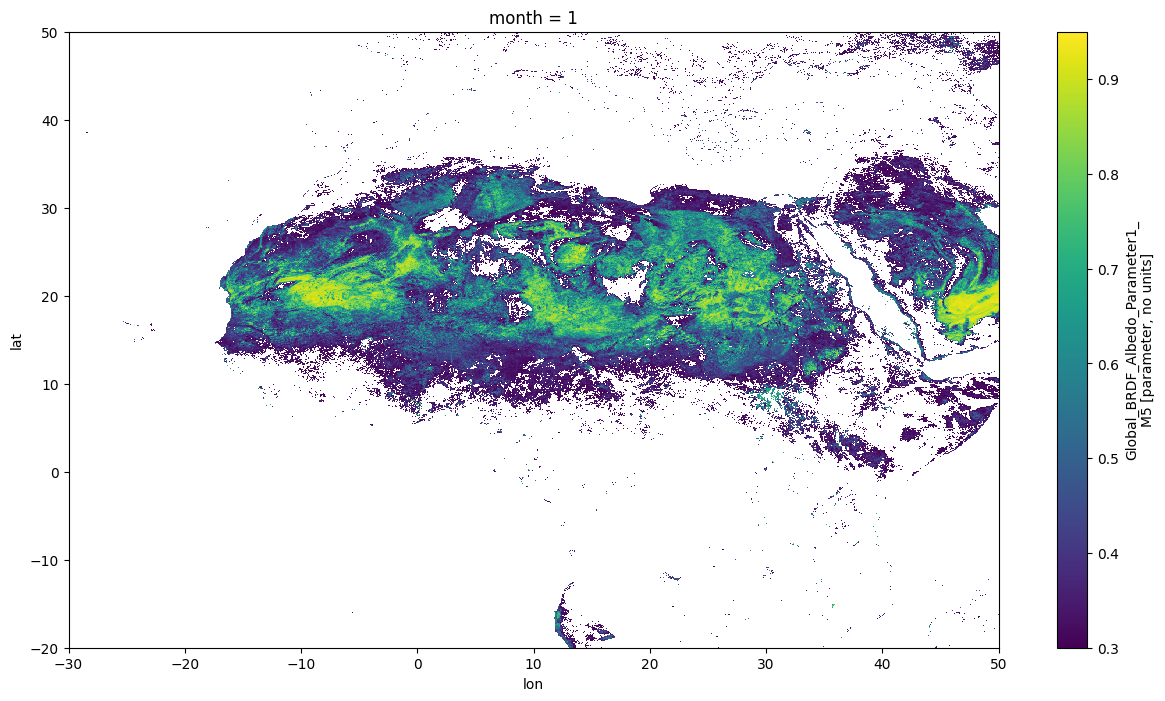

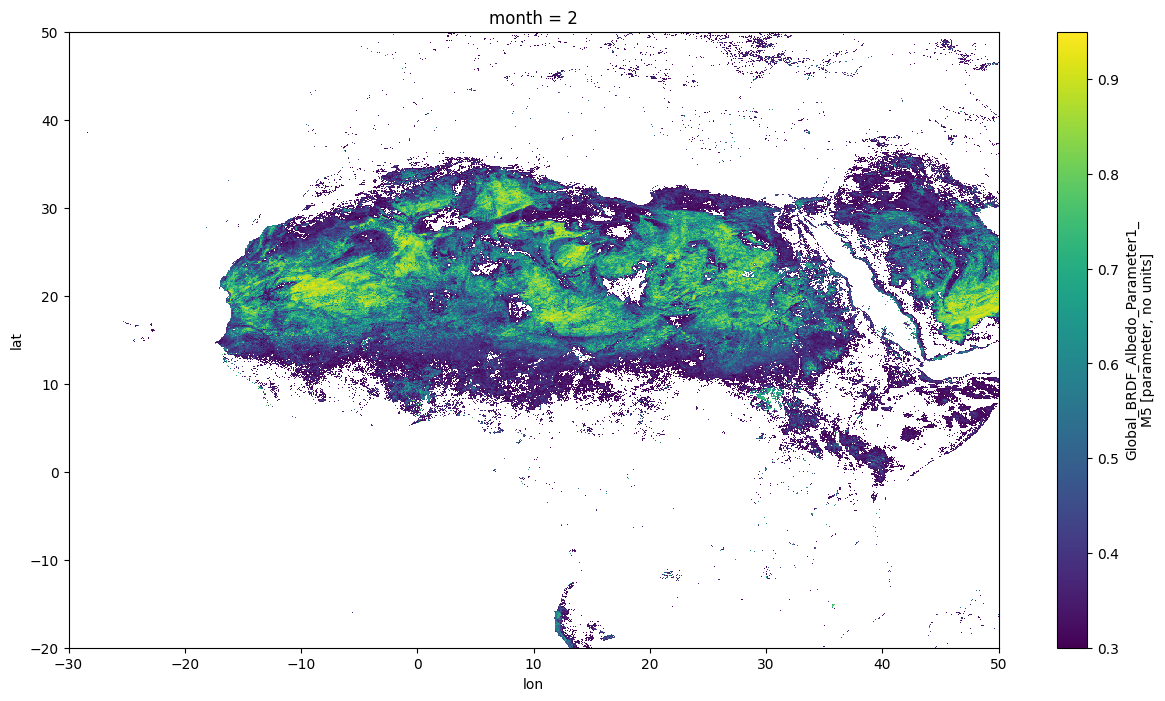

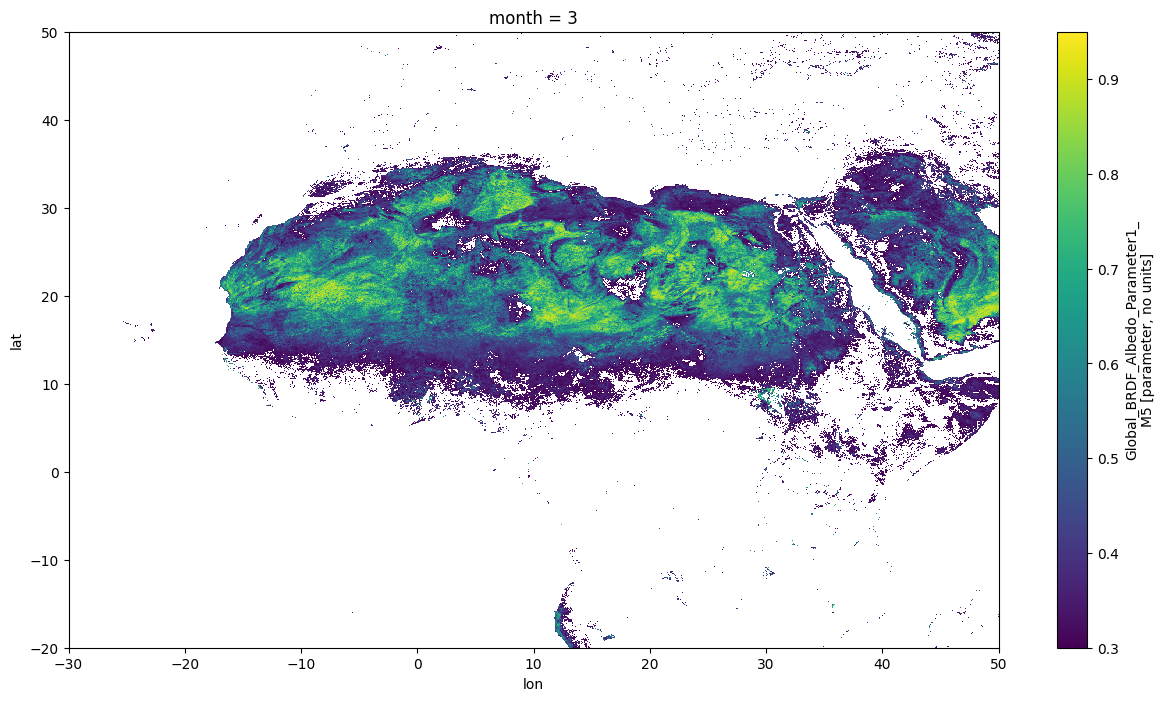

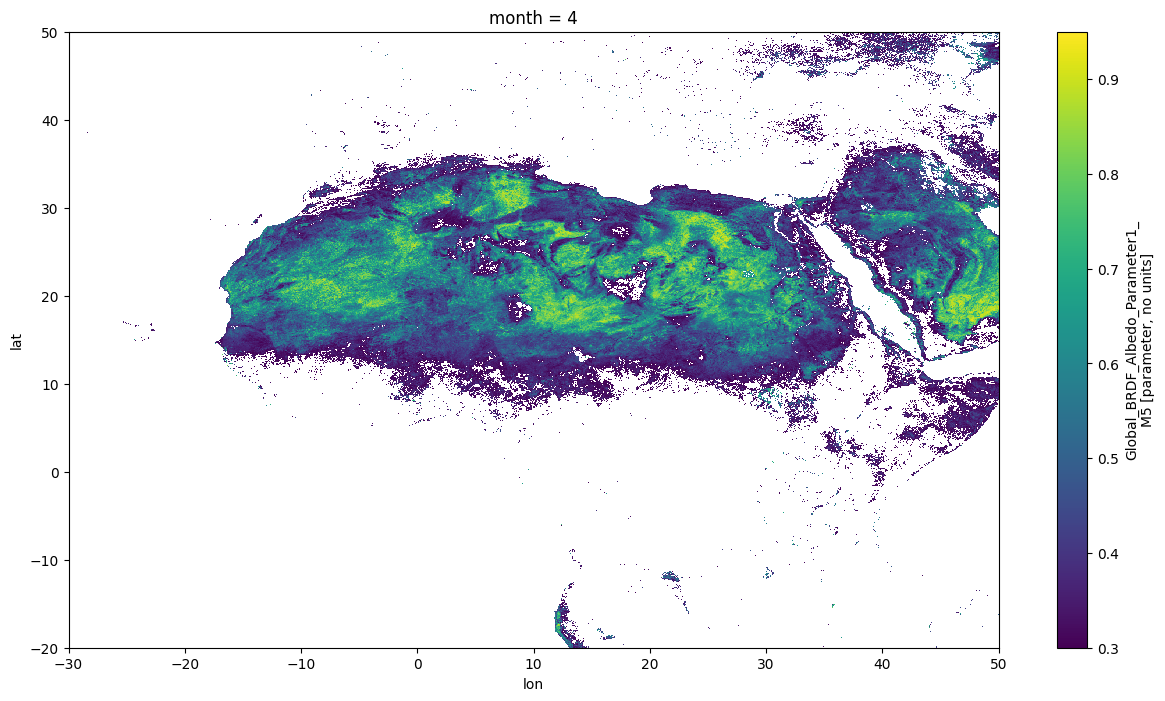

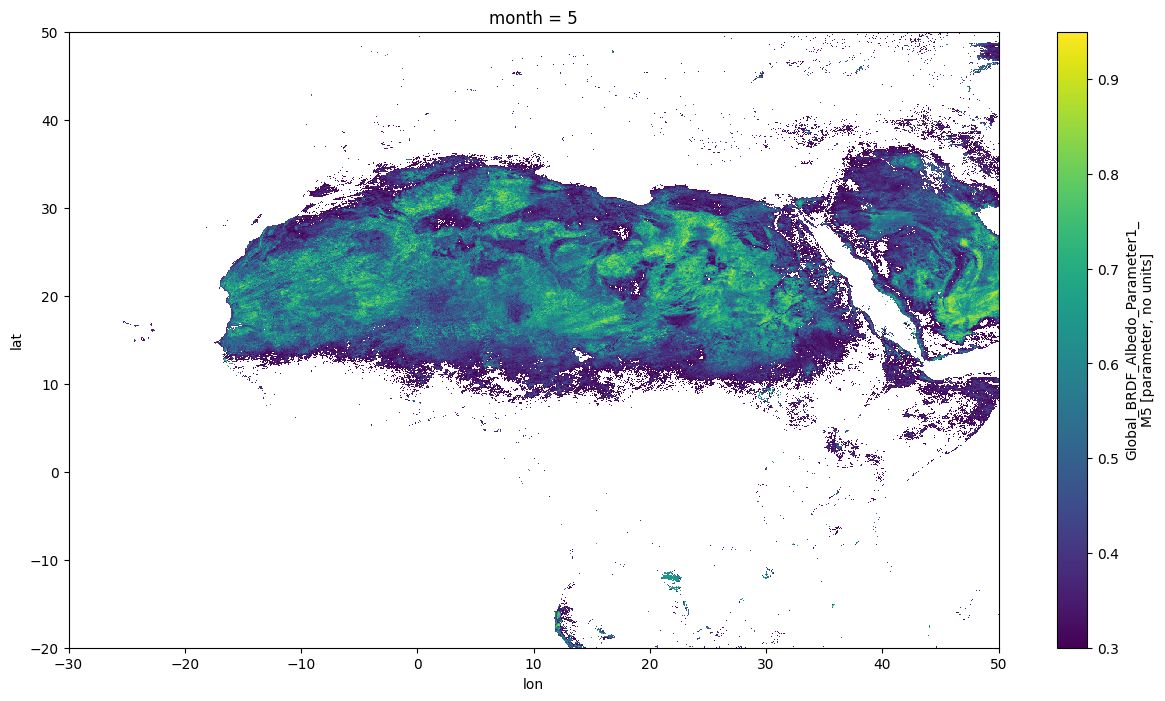

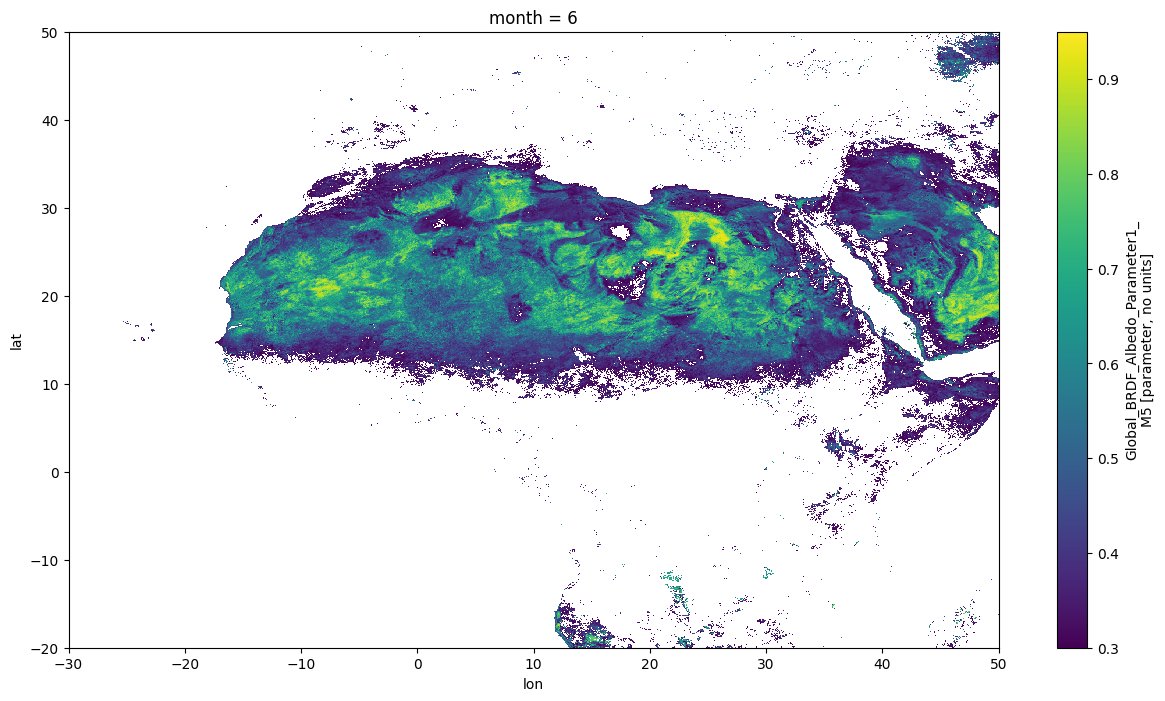

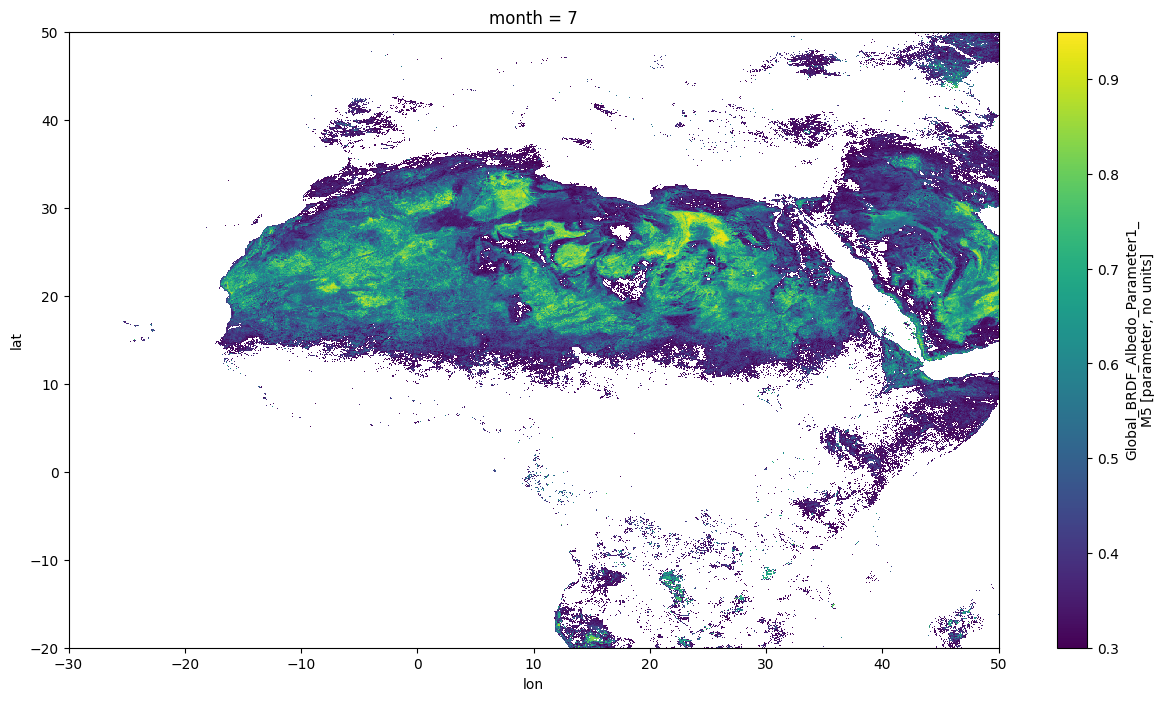

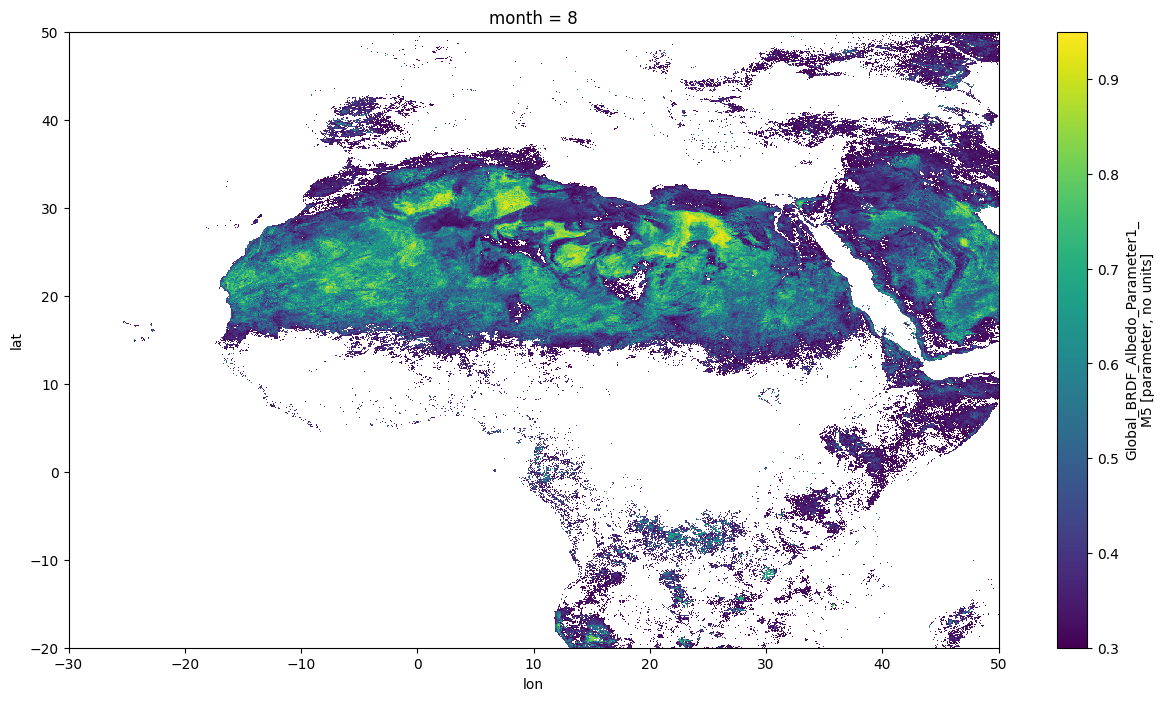

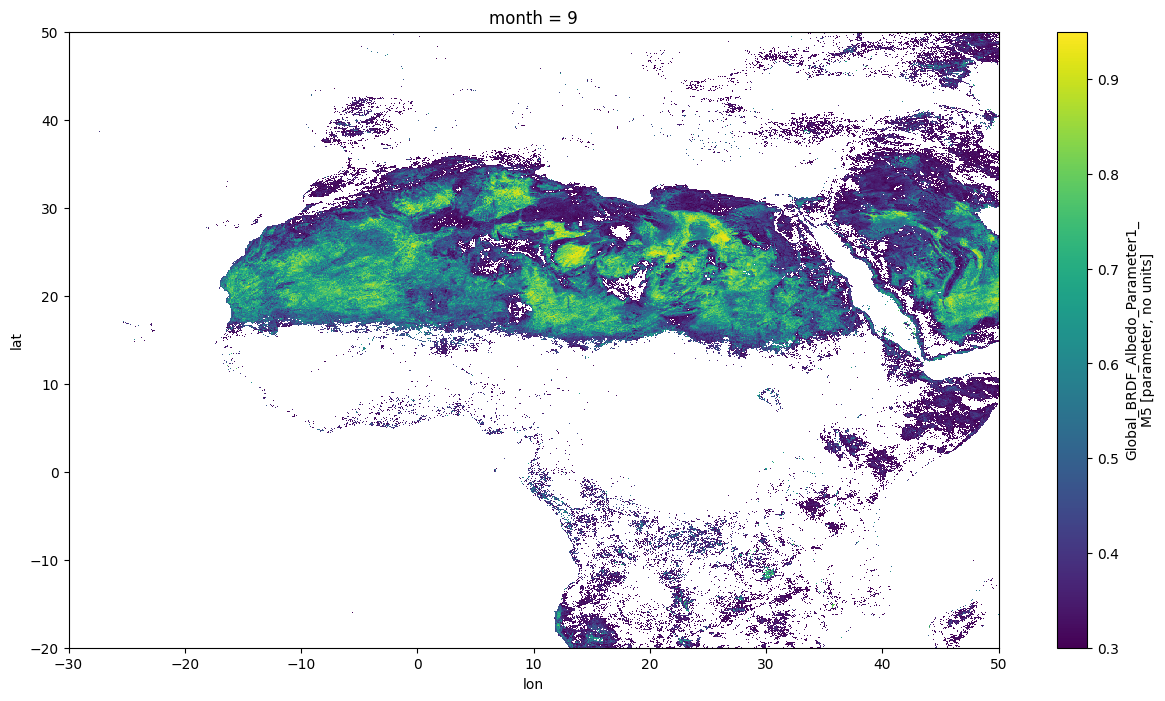

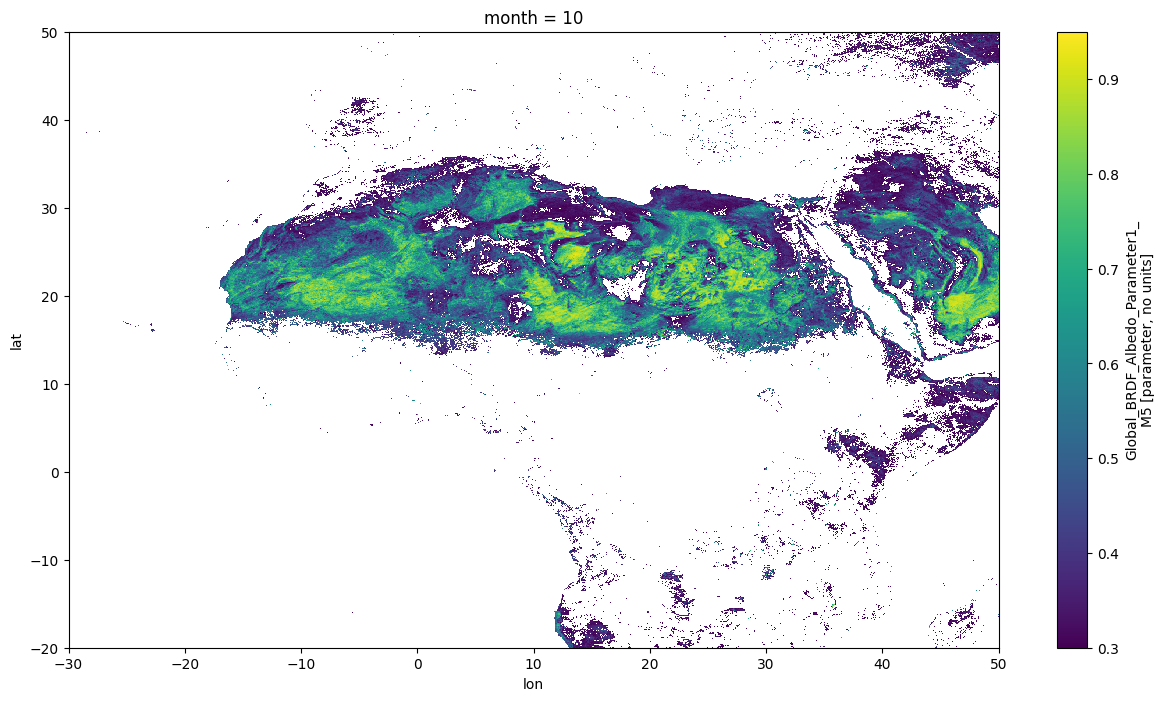

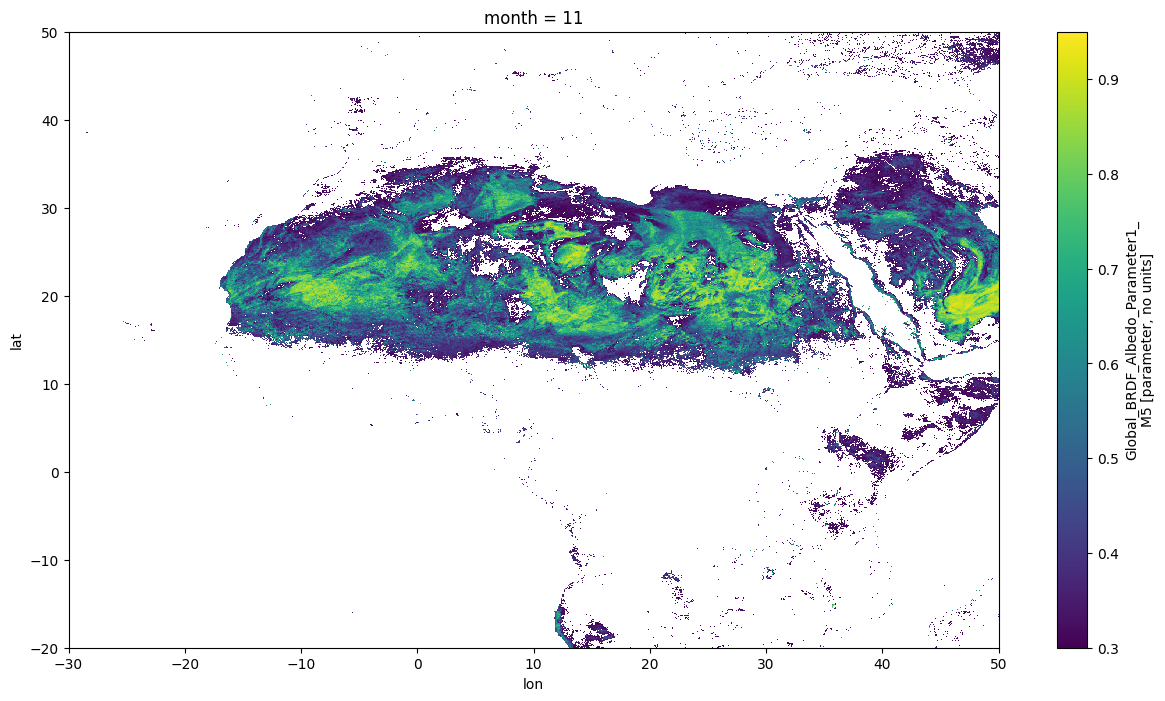

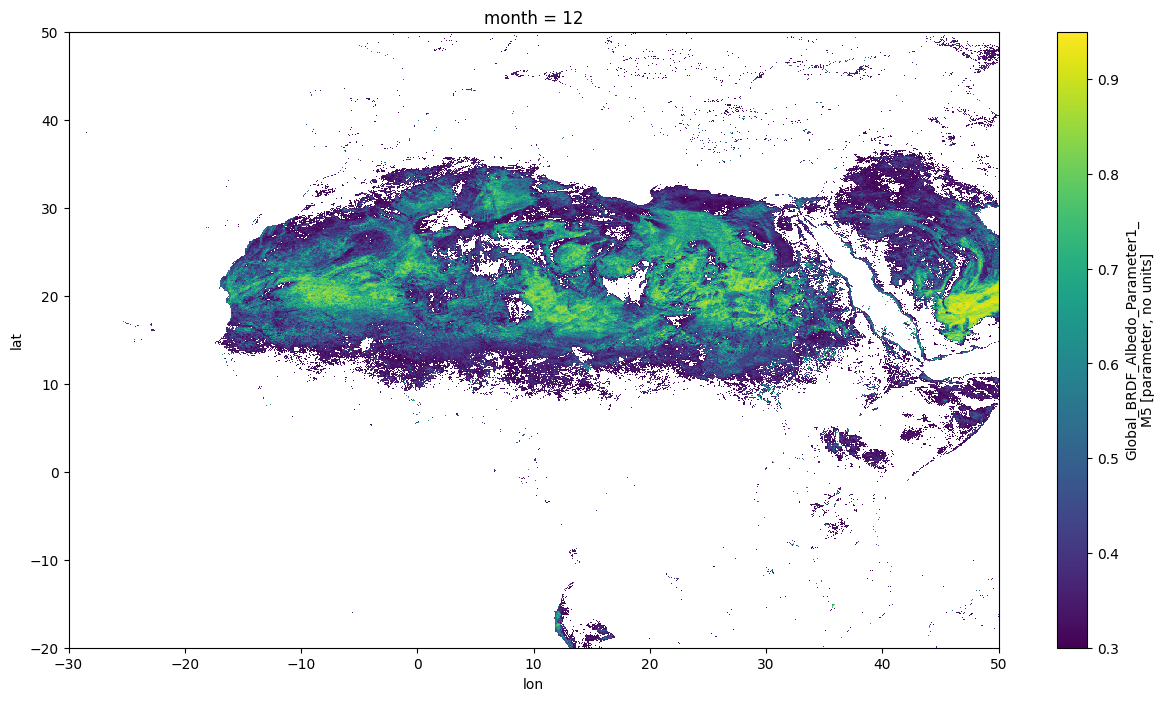

In [6]:
import matplotlib.pyplot as plt
for i in range(0,12):
    plt.figure(figsize=(15, 8))
    feff2.where(feff2 < 1).where(feff2 > .3).sel(month=i+1, lat=slice(50,-20), lon=slice(-30,50)).plot.imshow(x="lon", y="lat", cmap="viridis", vmin=0.3,vmax=0.95)

In [11]:
feff2 =feff2.rename({'month':'time'})

In [12]:
import pandas as pd
feff2['time'] = pd.date_range('2025-01-15', periods=12, freq='MS')

In [13]:
feff2

<xarray.DataArray (time: 12, lat: 3600, lon: 7200)> Size: 2GB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(12, 3600, 7200))
Coordinates:
  * time     (time) datetime64[us] 96B 2025-02-01 2025-03-01 ... 2026-01-01
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.82 ... -89.88 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    units:          parameter, no units
    valid_range:    [    0 32766]
    calibrated_nt:  5
    long_name:      Global_BRDF_Albedo_Parameter1_M5

In [15]:
feff2 = feff2.fillna(.00001)

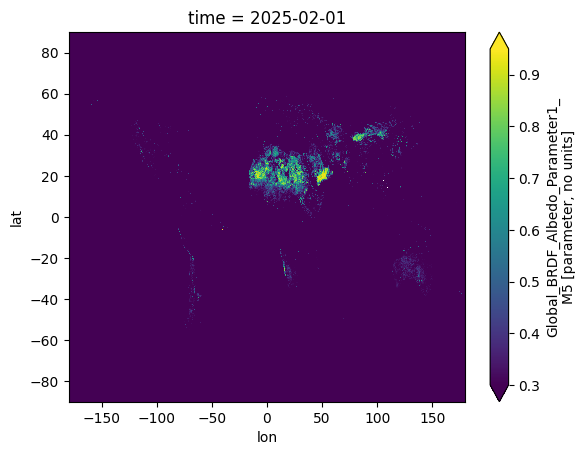

In [16]:
feff2.isel(time=0).plot.imshow(x="lon", y="lat", cmap="viridis", vmin=0.3,vmax=0.95)

In [17]:
feff2.to_dataset()

ValueError: unable to convert unnamed DataArray to a Dataset without providing an explicit name

In [18]:
feff2.name='albedo_drag'

In [35]:
feff = feff2.to_dataset()
encoding = {}
for i in feff.data_vars:
    encoding[i] = {'zlib': True, 'complevel': 5}
feff.to_netcdf('output/drag_partition_NESDIS_feff_monthly.nc', encoding=encoding)

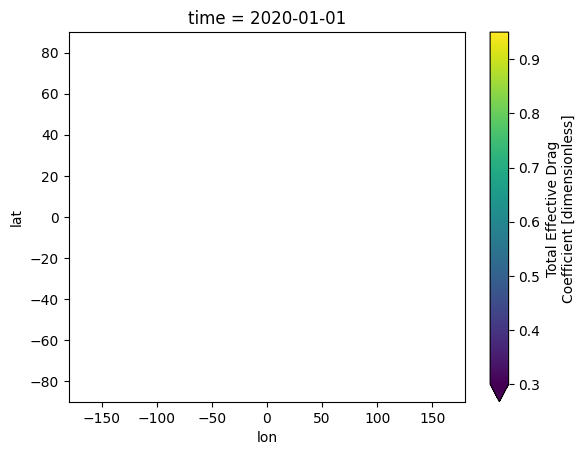

In [29]:
xr.open_dataset('output/drag_partition_VNP_2020-01-15.nc', engine='netcdf4').feff.isel(time=0).plot.imshow(x="lon", y="lat", cmap="viridis", vmin=0.3,vmax=0.95)

In [30]:
feff2

<xarray.DataArray 'albedo_drag' (time: 12, lat: 3600, lon: 7200)> Size: 2GB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(12, 3600, 7200))
Coordinates:
  * time     (time) datetime64[us] 96B 2025-02-01 2025-03-01 ... 2026-01-01
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.82 ... -89.88 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    units:          parameter, no units
    valid_range:    [    0 32766]
    calibrated_nt:  5
    long_name:      Global_BRDF_Albedo_Parameter1_M5